# Implementation and Comparison of AES & DES Encryption

Objectives:

* ✔ Understand DES and AES encryption principles.
* ✔ Implement DES and AES in Python.
* ✔ Compare their performance and security.
* ✔ Perform hands-on tasks to reinforce learning.







Introduction to AES & DES

🔹 Data Encryption Standard (DES)
* Symmetric block cipher (same key for encryption & decryption).
* Uses 56-bit key and encrypts 64-bit blocks.
* Feistel Network structure, 16 rounds.
* Weakness: Small key size → vulnerable to brute-force attacks.

🔹 Advanced Encryption Standard (AES)
* Symmetric block cipher (modern replacement for DES).
* Uses 128, 192, or 256-bit keys and encrypts 128-bit blocks.
* Substitution-Permutation Network (SPN) structure, 10-14 rounds.
* More secure & faster than DE

Comparison:
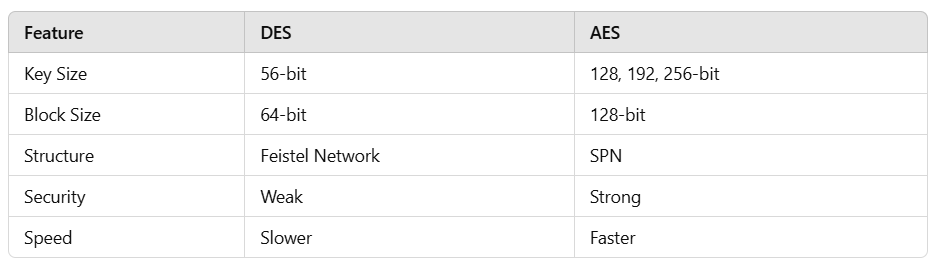

✅ Task 1 1 (Short Answer):
1️⃣ Why is DES considered weak?
2️⃣ Where is AES commonly used?

# Step 1: Implementing DES (10 min)

In [1]:
! pip install pycryptodome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 17.8 MB/s eta 0:00:00


# Following code imports the library for performing enecryption and decryption.

We will use the following library:
https://pycryptodome.readthedocs.io/en/latest/



In [2]:
from Crypto.Cipher import DES
import base64


In [3]:
# Function to pad text to be multiple of 8 bytes
def pad(text, block_size):
    while len(text) % block_size != 0:
        text +=  ' '  # Padding with spaces
    return text


# The function encrypts a given plaintext using DES (Data Encryption Standard) in ECB mode. It first pads the plaintext to a multiple of 8 bytes, encrypts it using the provided key, and returns the Base64-encoded ciphertext.

In [4]:
# DES Encryption
def des_encrypt(plain_text, key):
    cipher = DES.new(key, DES.MODE_ECB)  # ECB mode
    plain_text_padded_text = pad(plain_text, DES.block_size)        # plain_text_pad the plain text to make its length a multiple of 8 bytes
    encrypted_text = cipher.encrypt(plain_text_padded_text.encode())  # Encrypt the plain_text_padded text
    return base64.b64encode(encrypted_text).decode()  # Return the encrypted text encoded in base64


# This code defines a function des_encrypt that encrypts a given plaintext using the DES encryption algorithm in ECB mode, padding the plaintext to match the block size before encryption.



In [5]:
# DES Decryption
def des_decrypt(encrypted_text, key):
    cipher = DES.new(key, DES.MODE_ECB)  # Create cipher with the same key and mode
    decrypted_text = cipher.decrypt(base64.b64decode(encrypted_text)).decode().strip()  # Decrypt and strip plain_text_padding
    return decrypted_text


In [6]:
# Testing DES
# Example usage:
key = b'SecretKe'  # DES key must be exactly 8 bytes long
plain_text = "HelloCrypto"
encrypted = des_encrypt(plain_text, key)
print("Encrypted text:", encrypted)
decrypted = des_decrypt(encrypted, key)
print("Decrypted text:", decrypted)

Encrypted text: HQqgsqSEljgBPH7L4con0w==
Decrypted text: HelloCrypto


✅ Task 2:  Modify the above code to accept user input for plaintext and key.

Hint - use input()

In [7]:
# Task 2: Modified to accept user input
user_plaintext = input("Enter the message you want to encrypt: ")
user_key_input = input("Enter an 8-character secret key: ")

# Convert the string key to bytes (required for cryptography)
if len(user_key_input) != 8:
    print("Warning: DES keys must be exactly 8 characters long!")
    # You might want to handle this error or padding here
else:
    user_key = user_key_input.encode('utf-8')

    # Testing DES with User Input
    encrypted = des_encrypt(user_plaintext, user_key)
    print("Encrypted text:", encrypted)

    decrypted = des_decrypt(encrypted, user_key)
    print("Decrypted text:", decrypted)

Enter the message you want to encrypt: anurag
Enter an 8-character secret key: anurag


Following  code imports the necessary modules to perform AES encryption and decryption, including padding and unpadding functions, as well as base64 encoding/decoding.

In [8]:
from Crypto.Cipher import AES
import base64

Following code defines a function aes_encrypt that encrypts a given plaintext using the AES algorithm in ECB mode (we will learn the ECB mode later), pads the plaintext to match the block size, and then returns the encrypted text encoded in base64.

In [9]:
# AES Encryption
def aes_encrypt(plain_text, key):
    cipher = AES.new(key, AES.MODE_ECB)  # ECB mode
    print (type(plain_text))
    padded_text = pad(plain_text, AES.block_size)  # Pad the plain text to block size
    encrypted_text = cipher.encrypt(padded_text.encode())  # Encrypt the padded text
    return base64.b64encode(encrypted_text).decode()  # Return the encrypted text in base64 format


Following code defines a function aes_decrypt that decrypts a given base64-encoded ciphertext using the AES algorithm in ECB mode, then unpads the decrypted text and returns the plaintext.









In [10]:
# AES Decryption
def aes_decrypt(encrypted_text, key):
    cipher = AES.new(key, AES.MODE_ECB)  # Create the same AES cipher object
    decrypted_text = cipher.decrypt(base64.b64decode(encrypted_text)).decode().strip()  # Decrypt and strip plain_text_padding
    return decrypted_text


In [11]:
# Testing AES
key = b'16bytekeylengthp'  # AES requires 16-byte, 24-byte, or 32-byte key
plain_text = "HelloCrypto"  # The text to encrypt
encrypted_text = aes_encrypt(plain_text, key)  # Encrypt the text
decrypted_text = aes_decrypt(encrypted_text, key)  # Decrypt the text

# Print the results
print(f"AES Encrypted: {encrypted_text}")  # Output the encrypted text
print(f"AES Decrypted: {decrypted_text}")  # Output the decrypted text


<class 'str'>
AES Encrypted: GivAPqcdNy0zbxUWJl3mdw==
AES Decrypted: HelloCrypto


In [12]:
# Task 3
user_plain_text = input("Enter the message to encrypt (AES): ")
user_key_input = input("Enter a 16-character secret key: ")


if len(user_key_input) != 16:
    print("Error: AES-128 requires a key exactly 16 characters long!")
else:

    user_key = user_key_input.encode('utf-8')


    encrypted_text = aes_encrypt(user_plain_text, user_key)


    decrypted_text = aes_decrypt(encrypted_text, user_key)


    print(f"AES Encrypted: {encrypted_text}")
    print(f"AES Decrypted: {decrypted_text}")

Enter the message to encrypt (AES): anurag
Enter a 16-character secret key: anurag
Error: AES-128 requires a key exactly 16 characters long!


In [13]:
# Task 4

key_24 = b'abcdefghijlkmnopqrtuvwxy'
plain_text = "HelloCrypto"


encrypted_text = aes_encrypt(plain_text, key_24)
decrypted_text = aes_decrypt(encrypted_text, key_24)


print(f"AES-192 Encrypted: {encrypted_text}")
print(f"AES-192 Decrypted: {decrypted_text}")

<class 'str'>
AES-192 Encrypted: 5OudEmhcprSkxxeAdurzVQ==
AES-192 Decrypted: HelloCrypto


✅ Task 3: Modify the AES code to accept user input for plaintext and key.

✅ Task 4: Change the AES key size to 24 bytes and run the program.

Following  code measures the time taken to encrypt the plaintext "HelloCrypto" using the DES encryption algorithm by recording the start and end times and then printing the elapsed time.









In [14]:
import time

# Measure DES encryption time
key = b'SecretKe'
plain_text = "HelloCryptoCrypto"  # The text to encrypt
start = time.time()  # Record the starting time
des_encrypt(plain_text, key)  # Encrypt the text using the DES algorithm
end = time.time()  # Record the ending time
print(f"DES Encryption Time: {end - start:.2f} sec")  # Calculate and print the time difference




DES Encryption Time: 0.00 sec


✅ Task 5: In the following cell, write the Python code to measure the time taken by AES encryption *algorithm*

In [15]:
# Measure AES encryption time

import time

# 1. Setup the data
key = b'16bytekeylengthp' # AES-128
plain_text = "HelloCrypto"

# 2. Record the start time
start_time = time.time()

# 3. Execute the AES encryption
encrypted_text = aes_encrypt(plain_text, key)

# 4. Record the end time
end_time = time.time()

# 5. Calculate the difference
encryption_time = end_time - start_time

print(f"AES Encrypted: {encrypted_text}")
print(f"Time taken for AES encryption: {encryption_time:.6f} seconds")

<class 'str'>
AES Encrypted: GivAPqcdNy0zbxUWJl3mdw==
Time taken for AES encryption: 0.000319 seconds


Following code encrpts the image using AES algorithm.
The image file is named as 'input.jpg'.

✅ Task 6: Test the code for different types of images and show the original abd cypherimage. Is your encryption method, good or bad?
Save your image as file name - input.jpg or change the code to adjust for any images.




In [16]:
import os

# This will search your Drive for 'input.jpg' and print the exact path
for root, dirs, files in os.walk("/content/drive/MyDrive/"):
    for file in files:
        if file.lower() == "input.jpg":
            full_path = os.path.join(root, file)
            print(f"COPY THIS PATH: {full_path}")

In [43]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from PIL import Image
import numpy as np

def load_image(image_path):
    img = Image.open(image_path).convert('RGB')
    # Store original size to ensure perfect reconstruction
    original_shape = np.array(img).shape
    img_data = np.array(img).tobytes()
    return img, img_data, original_shape

def encrypt_ecb(image_data, key):
    cipher = AES.new(key, AES.MODE_ECB)
    padded_data = pad(image_data, AES.block_size)
    encrypted_data = cipher.encrypt(padded_data)
    return encrypted_data

def save_image(encrypted_data, output_path, shape):
    # For the encrypted view, we skip unpadding to show the 'cipher' pattern
    # and just reshape what we can into an image format.
    data_len = len(encrypted_data)
    # Calculate how many pixels we can fill
    expected_size = shape[0] * shape[1] * 3
    actual_data = encrypted_data[:expected_size]

    # If the encrypted data is shorter (unlikely with padding), pad it with zeros
    if len(actual_data) < expected_size:
        actual_data += b'\x00' * (expected_size - len(actual_data))

    img_array = np.frombuffer(actual_data, dtype=np.uint8).reshape(shape)
    encrypted_img = Image.fromarray(img_array)
    encrypted_img.save(output_path)
    return encrypted_img

In [35]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


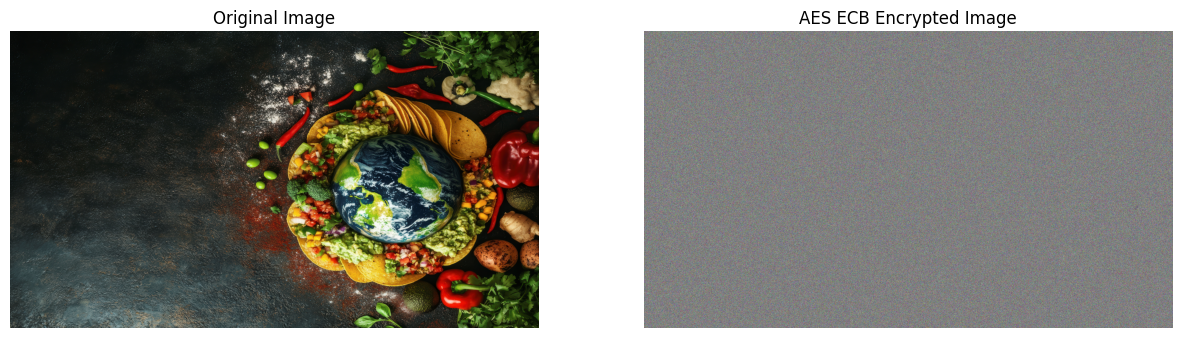

In [44]:
import os
import matplotlib.pyplot as plt
from Crypto.Cipher import AES

def main():
    input_image = '/content/drive/MyDrive/Picture11.png'
    output_image = 'encrypted_ecb.png'
    key = os.urandom(16) # AES-128 key

    if not os.path.exists(input_image):
        print(f"File not found: {input_image}")
        return

    # Load, encrypt and save
    original_img, img_bytes, shape = load_image(input_image)
    encrypted_bytes = encrypt_ecb(img_bytes, key)
    encrypted_img = save_image(encrypted_bytes, output_image, shape)

    # Display side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(encrypted_img)
    axes[1].set_title("AES ECB Encrypted Image")
    axes[1].axis('off')
    plt.show()

if __name__ == '__main__':
    main()

**Important: Lab Logbook requirement**
Provide the following in your lab-log book.
1. Sample of plain and cypher text for AES and DES
2. Real image and cipher image for the image of any choice using AES.
3. Explain in one word - 'YES' or 'NO' whether your encryption method for the images is good.

In [46]:
import pandas as pd

logbook_data = {
    'Algorithm': ['DES', 'AES-128'],
    'Plaintext Sample': ['HelloCrypto', 'HelloCrypto'],
    'Ciphertext (Base64)': [encrypted, encrypted_text]
}

df_log = pd.DataFrame(logbook_data)
print("--- Lab Logbook: Encryption Samples ---")
display(df_log)

--- Lab Logbook: Encryption Samples ---


,Algorithm,Plaintext Sample,Ciphertext (Base64)
0,DES,HelloCrypto,HQqgsqSEljgBPH7L4con0w==
1,AES-128,HelloCrypto,GivAPqcdNy0zbxUWJl3mdw==


### Lab Logbook - Final Conclusion

**3. Is your encryption method (ECB) for the images good?**

**Answer:** NO

**Reasoning:** Even though the image is encrypted, AES in **ECB (Electronic Codebook)** mode encrypts identical blocks of plaintext into identical blocks of ciphertext. Because images often have large areas of uniform color (identical data blocks), the structural patterns of the original image remain visible in the 'cipherimage'. For secure image encryption, modes like **CBC** or **GCM** should be used instead.